# Lecture 7

In [1]:
import sys
sys.path.append("..")

# load standard libraries
import numpy as np   # standard numerics library
import numpy.linalg as LA
from scipy.integrate import ode
import matplotlib.pyplot as plt   # for making plots
import time as time
import scipy.sparse as sparse
import scipy.sparse.linalg as sLA
from scipy.special import comb

import Comp_Quant_Dynam as cqd

# 1) Visualizing collective spins

recall **Bloch sphere** for spin $1/2$
$$\lvert\psi\rangle = \cos\frac{\theta}{2}\lvert0\rangle + e^{i\varphi}\sin\frac{\theta}{2}\lvert1\rangle$$

$N$ spins $\rightarrow$ could plot $(\langle S_x\rangle, \langle S_y\rangle, \langle S_z\rangle)$ in a 3D space
* **but:** Is not restricted to surface (eg. $\lvert\psi\rangle = \frac{1}{\sqrt{2}}(\lvert0...0\rangle + \lvert1...1\rangle)$) $\rightarrow \langle S_\alpha\rangle = 0 \quad \forall \alpha$
* Has no information about higher moments (eg. $\langle S_\alpha^2\rangle$)

$\Rightarrow$ Use **projections on spin coherent states (CSS)**
$\rightarrow$ **Husimi function** (quasi-probability)

## Coherent states:
$$\lvert\text{CSS}(\theta,\varphi)\rangle \equiv \lvert\theta,\varphi\rangle = \bigotimes_{j=1}^{N} \left(\cos\frac{\theta}{2}\lvert0\rangle_j + e^{i\varphi}\sin\frac{\theta}{2}\lvert1\rangle_j\right)$$

* (all spins in the same state)
* 2-parameter family of states.

$$= \sum_{k=0}^{N} \sqrt{\binom{N}{k}} \left(\cos\frac{\theta}{2}\right)^k \left(\sin\frac{\theta}{2}\right)^{N-k} e^{i k \varphi} \lvert k \rangle$$
$$\uparrow \text{sym. Dicke states}$$

$$H_Q(\theta,\varphi) = \lvert\langle\theta,\varphi\vert\psi\rangle\rvert^2 \qquad \theta \in [0,\pi] \; , \; \varphi \in [0,2\pi)$$

## Quasi-probability distribution
* positive, normalizable
* not mutually exclusive ($\lvert\theta,\varphi\rangle$ are not orthogonal to each other)

Husimi function is a "phase space" representation closely related to the **Wigner function** via
$$H_Q(\theta,\varphi) = \int d\tilde{\theta} \, d\tilde{\varphi} \, W(\tilde{\theta},\tilde{\varphi}) \, e^{-2\lvert\theta-\tilde{\theta}\rvert^2 - 2\lvert\varphi-\tilde{\varphi}\rvert^2} \quad \text{(Weierstrass transform)}$$

and to the **Glauber-Sudarshan P representation**.

### example: Husimi fct. of $\lvert\psi\rangle = \lvert0...0\rangle$

$$H_Q(\theta,\varphi) = \lvert\langle\psi\vert\theta,\varphi\rangle\rvert^2 = \left(\cos\frac{\theta}{2}\right)^{2N}$$

* gets more peaked at $\theta = 0$ for larger $N$

$H_Q(\theta,\varphi)$ contains the **full information** about the state!

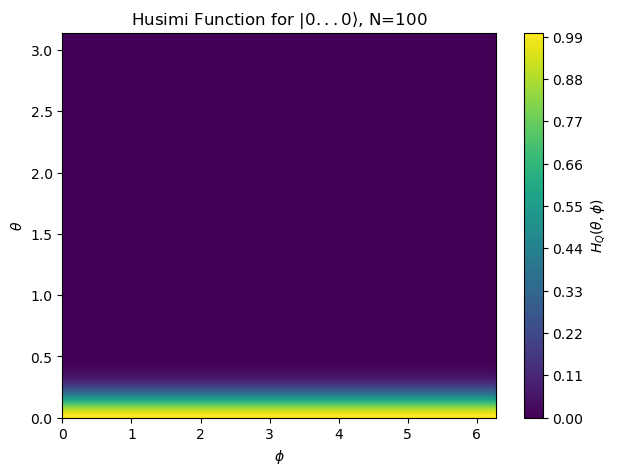

In [2]:
# Number of spins
N = 100

# Grid
theta = np.linspace(0, np.pi, 200)
phi = np.linspace(0, 2*np.pi, 200)
Theta, Phi = np.meshgrid(theta, phi)
# Husimi function 
HQ = np.cos(Theta/2)**(2*N)

# Plot
plt.figure(figsize=(7,5))
plt.contourf(Phi, Theta, HQ, levels=100)
plt.colorbar(label=r"$H_Q(\theta,\phi)$")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\theta$")
plt.title(f"Husimi Function for $|0...0\\rangle$, N={N}")
plt.show()

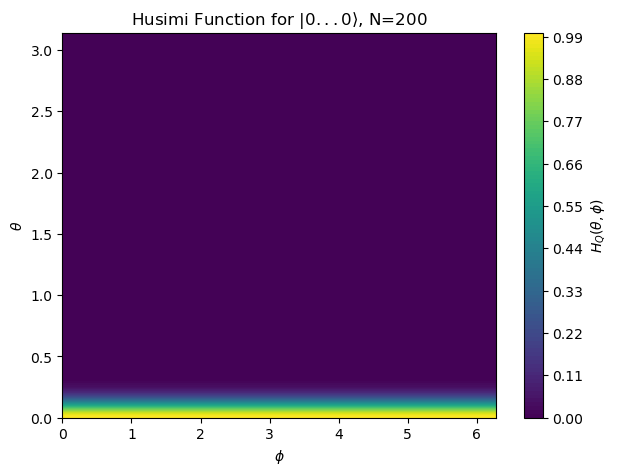

In [3]:
# Number of spins
N = 200

# Grid
theta = np.linspace(0, np.pi, 200)
phi = np.linspace(0, 2*np.pi, 200)
Theta, Phi = np.meshgrid(theta, phi)
# Husimi function 
HQ = np.cos(Theta/2)**(2*N)

# Plot
plt.figure(figsize=(7,5))
plt.contourf(Phi, Theta, HQ, levels=100)
plt.colorbar(label=r"$H_Q(\theta,\phi)$")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\theta$")
plt.title(f"Husimi Function for $|0...0\\rangle$, N={N}")
plt.show()

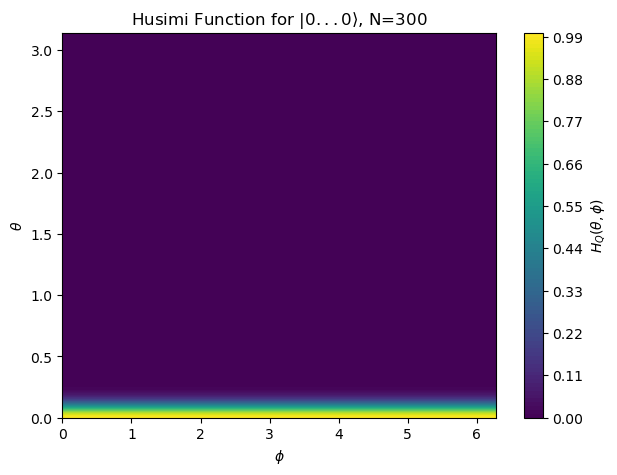

In [4]:
# Number of spins
N = 300

# Grid
theta = np.linspace(0, np.pi, 200)
phi = np.linspace(0, 2*np.pi, 200)
Theta, Phi = np.meshgrid(theta, phi)
# Husimi function 
HQ = np.cos(Theta/2)**(2*N)

# Plot
plt.figure(figsize=(7,5))
plt.contourf(Phi, Theta, HQ, levels=100)
plt.colorbar(label=r"$H_Q(\theta,\phi)$")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\theta$")
plt.title(f"Husimi Function for $|0...0\\rangle$, N={N}")
plt.show()

## 2) Properties of coherent spin state (CSS):

* **Spin length**

$$
|\langle \vec{S} \rangle|
=
\sqrt{\langle S_x\rangle^2 + \langle S_y\rangle^2 + \langle S_z\rangle^2}
=
\frac{N}{2}
$$

$$
\left(
\langle S_\alpha\rangle
=
N\,\langle S_\alpha^{(1)}\rangle,
\qquad
|\langle \vec{S}^{(1)}\rangle|
=
\sqrt{\langle \vec{S}^{(1)}\rangle^2}
=
\frac{1}{2}
\right)
$$

* can be generated from $\lvert\psi\rangle = \lvert0...0\rangle$ :
  $$\lvert\theta,\varphi\rangle = e^{-i\varphi S_z} e^{-i\theta S_y} \lvert0...0\rangle \equiv U(\theta,\varphi)\lvert0...0\rangle$$

* **variances:** $$\Delta^2 S_{\parallel} = 0 \qquad \text{(parallel to } \langle\vec{S}\rangle\text{)}$$
  $$\Delta^2 S_{\perp} = \frac{N}{4} \qquad \text{variances are additive for CSS, i.e. } N \times \text{single spin value}$$

  > **(verify for $\lvert\psi\rangle = \lvert0...0\rangle$ :** > $$S_z \lvert\psi\rangle = \frac{N}{2}\lvert\psi\rangle \qquad \text{with } S_z = S_{\parallel}$$
  > $$\langle\psi\rvert S_z^2 \lvert\psi\rangle = \left(\frac{N}{2}\right)^2 = \langle\psi\rvert S_z \lvert\psi\rangle^2 \implies \Delta^2 S_z = 0$$
  > $$S_x \lvert\psi\rangle = \frac{1}{2}\sqrt{N}\lvert N-1\rangle \implies \langle S_x\rangle = \langle S_y\rangle = 0 \quad (= \langle S_{\perp}\rangle)$$
  > $$\langle\psi\rvert S_x^2 \lvert\psi\rangle = \frac{N}{4} \implies \Delta^2 S_x = \frac{N}{4} \quad )$$

* **uncertainty rel** $$\Delta^2 S_x \Delta^2 S_y \ge \frac{1}{4} \lvert\langle [S_x, S_y] \rangle\rvert^2 = \frac{1}{4} \lvert\langle -i S_z \rangle\rvert^2$$
  $$\frac{N}{4} \cdot \frac{N}{4} \equiv \frac{1}{4}\left(\frac{N}{2}\right)^2 \rightarrow \text{minimal uncertainty states} \rightarrow \text{"classical states"}$$

---

$$\frac{\Delta^2 S_{\perp}}{\langle\vec{S}\rangle^2} = \frac{1}{N} \rightarrow \text{While spin length grows } \propto N\text{, "width" } \Delta S_{\perp} \text{ only grows } \propto \sqrt{N}$$

$$\boxed{\frac{1}{N} = \hbar_{\text{eff}}} \rightarrow 0$$

$\Rightarrow$ For large $N$, coherent states become **points** on the Bloch sphere / in phase space.

$\Rightarrow$ Notion of **classical trajectories is recovered!**

$\rightarrow$ Motivation for studying **semi-classical physics** in terms of the coherent state representation ($H_Q$).

$\Rightarrow$ **Efficient numerical methods!**

## 3) Mean-field approximation

Consider coll. Ising model again:
$$H = -\frac{1}{N} \hat{S}_z^2 - \Omega \hat{S}_x$$

### Heisenberg equations of motion for Operators:
$$\frac{d}{dt} \hat{A}(t) = i [\hat{H}, \hat{A}(t)]$$

> **(equiv. to SE:**
> $$\frac{d}{dt} \hat{A}(t) = \frac{d}{dt} \left( e^{i\hat{H}t} \hat{A}(0) e^{-i\hat{H}t} \right)$$
> $$= e^{i\hat{H}t} i\hat{H}\hat{A} e^{-i\hat{H}t} + e^{i\hat{H}t} \hat{A}(-i\hat{H}) e^{-i\hat{H}t}$$
> $$= i [\hat{H}, \hat{A}] \quad )$$

recall: $[\hat{S}_x, \hat{S}_y] = i\hat{S}_z$
$+\text{ cyclic perm.}$

---

$$\frac{d}{dt} \hat{S}_x = i \left[ -\frac{1}{N}\hat{S}_z^2 - \Omega\hat{S}_x, \hat{S}_x \right]$$
$$= -\frac{i}{N} \Big( \hat{S}_z \underbrace{[\hat{S}_z, \hat{S}_x]}_{i\hat{S}_y} + \underbrace{[\hat{S}_z, \hat{S}_x]}_{i\hat{S}_y} \hat{S}_z \Big) = \frac{1}{N} (\hat{S}_z \hat{S}_y + \hat{S}_y \hat{S}_z)$$

$$\frac{d}{dt} \hat{S}_y = -\frac{1}{N} (\hat{S}_z \hat{S}_x + \hat{S}_x \hat{S}_z) + \Omega \hat{S}_z$$

$$\frac{d}{dt} \hat{S}_z = -\Omega \hat{S}_y$$

* $\Rightarrow$ RHS contains products $\hat{S}_\alpha \hat{S}_B$
* $\Rightarrow$ Would need eom. for these
* $\Rightarrow$ **Hierarchy of eq's**

truncate the hierarchy at lowest order
$$\hat{S}_\alpha = \langle \hat{S}_\alpha \rangle + \delta\hat{S}_\alpha = \underbrace{S_\alpha}_{O(N)} + \underbrace{O(1)}_{\text{neglect}} \qquad \text{argument: fluct. are order lower in } N$$

$S_\alpha$: "classical" field

With this, taking expectation values of the Heisenberg eq's:
$$\langle \hat{S}_\alpha \hat{S}_\beta \rangle \approx S_\alpha S_\beta$$

$$\begin{aligned}
\Rightarrow \quad \dot{S}_x &= \frac{2}{N} S_z S_y \\
\dot{S}_y &= -\frac{2}{N} S_z S_x + \Omega S_z \\
\dot{S}_z &= -\Omega S_y
\end{aligned}
\xrightarrow[\alpha = \frac{S_\alpha}{N/2}]{\text{rescale}}
\begin{aligned}
\dot{x} &= yz \\
\dot{y} &= -xz + \Omega z \\
\dot{z} &= -\Omega y
\end{aligned}$$

$$\text{classical variables } \in [-1, 1]$$

constraint: $\vec{S}^2 = \left(\frac{N}{2}\right)^2 \iff x^2 + y^2 + z^2 = 1$
$$\rightarrow \text{live on surface of sphere}$$

$\Rightarrow$ 2D phase space, parametrize by $z$ and angle $\varphi$
$$x = \sqrt{1-z^2}\cos\varphi \qquad y = \sqrt{1-z^2}\sin\varphi$$

Can substitute in the above eom to obtain eom for $z, \varphi$
$$\rightarrow \text{see exercise}$$

It turns out that $z, \varphi$ are conjugate variables in the classical Hamiltonian
$$h_{\text{mf}} = \frac{H_{\text{mf}}}{N/2} = -\frac{1}{2}z^2 - \Omega\sqrt{1-z^2}\cos\varphi$$

Verify that Hamilton's equations $\dot{z} = -\frac{\partial h_{\text{mf}}}{\partial \varphi}$, $\dot{\varphi} = \frac{\partial h_{\text{mf}}}{\partial z}$ yield the same eom for $z, \varphi$ as above!

Studying the phase space contours, we can understand many features observed in the ED (Exact Diagonalization) study from exercise 5.

**Phase space contours = Isoenergy lines**, on which the system evolves (trajectories)

### example $\Omega \approx 0.5$
* **Minima** and **Maximum** points are indicated within the closed contours.
* **Saddle point** is located at the intersection of the boundaries.
* **"separatrix"** defines the boundary separating different types of dynamical trajectories.

---

### Mean field ground states?

Minima of $h_{\text{mf}}$ are on $\varphi = 0$ line
$$h_{\text{mf}}(z, \varphi=0) = -\frac{z^2}{2} - \Omega\sqrt{1-z^2}$$

#### Energy landscapes for different regimes of $\Omega$:

1. **$\Omega < \frac{1}{2}$**
   * Two symmetric minima corresponding to a degenerate **ground state** (spontaneous symmetry breaking).
   * The local maximum at $z=0$ has a value of $-\Omega$.
   * At the boundaries $z = \pm 1$, the energy value is $-\frac{1}{2}$ (with the initial state $\lvert0...0\rangle$ sitting at $z=1$).

2. **$\frac{1}{2} < \Omega < 1$**
   * The landscape alters as $\Omega$ increases, shifting the positions of the minima and lowering the central barrier.

3. **$\Omega > 1$**
   * A single global minimum forms at $z = 0$, reflecting a symmetric phase.

$\Rightarrow$ **ground state magnetization, phase transition and dynamical phase transition can all be understood!**

## 4) Schwinger boson representation

*(More rigorous way of deriving the mean field Hamiltonian)*

Dicke state Hilbert space maps to a **2-site Hubbard model (quantum dimer)**

* **states:** $$\lvert k \rangle \quad \begin{matrix} k \text{ spins in state } \lvert0\rangle \\ N-k \quad \text{"} \quad \text{"} \quad \lvert1\rangle \end{matrix} \iff \begin{matrix} k \text{ particles in well A} \\ N-k \quad \text{"} \quad \text{"} \quad \text{well B} \end{matrix}$$
  $$\lvert n_A, n_B \rangle = \lvert k, N-k \rangle \quad \text{"Fock space"}$$
  *(like coupled HO's)*

* **operators:**
  $$\begin{aligned}
  S_+ &\longleftrightarrow a^\dagger b \\
  S_x &\longleftrightarrow \frac{1}{2}(a^\dagger b + b^\dagger a) \\
  S_z &\longleftrightarrow \frac{1}{2}(n_A - n_B)
  \end{aligned}$$

---

### All matrix elements are the same under this mapping
$$\text{(recall HO : } a^\dagger \lvert n \rangle = \sqrt{n+1}\lvert n+1 \rangle \;, \; a\lvert n \rangle = \sqrt{n}\lvert n-1 \rangle \text{)}$$

$$a^\dagger b \lvert n_A, n_B \rangle = \sqrt{n_A+1}\sqrt{n_B} \lvert n_A+1, n_B-1 \rangle$$
$$S_+ \lvert k \rangle = \sqrt{(k+1)(N-k)} \lvert k+1 \rangle$$

$$\begin{aligned}
S_z^2 \longrightarrow \left(\frac{1}{2}(n_A - n_B)\right)^2 &= \frac{1}{4}(n_A^2 + n_B^2 - 2n_A n_B) \\
&= \frac{1}{4}\big(2n_A^2 + 2n_B^2 - \underbrace{(n_A + n_B)^2}_{\text{const. } \Rightarrow \text{ drop}}\big) \\
&= \frac{1}{2}\Big(n_A(n_A-1) + n_B(n_B-1) + \underbrace{\frac{1}{2}(n_A+n_B) - \frac{1}{4}(n_A+n_B)^2}_{\text{const. } \Rightarrow \text{ drop}}\Big)
\end{aligned}$$

$$\boxed{H = -\frac{1}{N} \left( \frac{n_A(n_A-1)}{2} + \frac{n_B(n_B-1)}{2} \right) - \frac{\Omega}{2}(a^\dagger b + b^\dagger a)}$$
$$\underbrace{\qquad\qquad\qquad\qquad\qquad\qquad}_{\text{on-site interaction}} \quad \underbrace{\qquad\qquad\qquad\qquad}_{\text{tunneling}}$$

$$\text{2-site Bose Hubbard model.}$$

### Derive mean-field equations:

$$H = -\frac{1}{4N} (\hat{n}_A - \hat{n}_B)^2 - \frac{\Omega}{2} (\hat{a}^\dagger\hat{b} + \hat{b}^\dagger\hat{a})$$

$$\hat{a} \rightarrow \sqrt{n_A} e^{i\varphi_A} \quad (+\delta\hat{a}) \qquad \hat{b} \rightarrow \sqrt{n_B} e^{i\varphi_B} \quad (+\delta\hat{b})$$
$$\text{classical variables (fields): amplitude and phase are conj. var.}$$

> **(alternatively**
> $$\begin{aligned}
  \hat{a} &= \hat{x} + i\hat{p} \rightarrow x + ip \\
  \hat{a}^\dagger &= \hat{x} - i\hat{p} \rightarrow x - ip
  \end{aligned}$$
> $\Rightarrow$ conjugate class. variables $x, p$ for each mode
> $\Rightarrow$ going to var. $\sqrt{n}, \varphi$ is canonical trafo **)**

---

$$\Rightarrow H_{\text{mf}} = -\frac{1}{4N} \underbrace{(n_A - n_B)^2}_{\Delta N \;,\; m \,=\, \frac{\Delta N}{N}} - \frac{1}{2}\Omega\sqrt{n_A n_B} \underbrace{\left( e^{-i\varphi_A + i\varphi_B} + e^{-i\varphi_B + i\varphi_A} \right)}_{2\cos(\varphi_A - \varphi_B) \;\rightarrow\; \Delta\varphi}$$

$$\sqrt{n_A n_B} = \frac{1}{2}\sqrt{(N + \Delta N)(N - \Delta N)} = \frac{N}{2}\sqrt{1 - m^2}$$

$$\Rightarrow h_{\text{mf}} = \frac{H_{\text{mf}}}{N/2} = -\frac{1}{2}m^2 - \Omega\sqrt{1-m^2}\cos\Delta\varphi \qquad \text{as before.}$$

$$\text{N is conserved, } \varphi_A + \varphi_B \text{ is cyclic} \Rightarrow \text{2D phase space}$$

## 5) Truncated Wigner approximation

**Idea:** Take the quantum noise in the initial state into account by randomly choosing initial phase space points according to the noise distribution (Wigner function) and evolve all these points according to the mean-field eom's and calculate observables by averaging over the sampled trajectories.

---

### example: Initial state $\lvert\psi_0\rangle = \lvert0...0\rangle$ (coherent spin state)

* $\rightarrow$ Noise is Gaussian around the mean
  $$(S_x, S_y, S_z) = \left(0, 0, \frac{N}{2}\right)$$
  with variances
  $$\left(\Delta^2 S_x, \Delta^2 S_y, \Delta^2 S_z\right) = \left(\frac{N}{4}, \frac{N}{4}, 0\right)$$

* $\rightarrow$ sample $S_x, S_y$ from a Gaussian around $0$ and use $S_z = \frac{N}{2}$ as initial cond.

### calculate observables like
$$\langle\hat{S}_x\rangle = \frac{1}{n_{\text{samples}}} \sum_{i=1}^{n_{\text{samples}}} S_x(\text{traj } i) \equiv \langle\langle S_x \rangle\rangle$$

$$\langle\hat{S}_x^2\rangle = \frac{1}{n_{\text{samples}}} \sum_{i=1}^{n_{\text{samples}}} \left(S_x(\text{traj } i)\right)^2 \equiv \langle\langle S_x^2 \rangle\rangle$$

This method can be proven to be exact at short times and in the large $N$ limit (for initial coherent states).

### References:
* A. Polkovnikov, Boulder summer school lecture notes
* A. Polkovnikov, *Ann. Phys.* **325**, 1790 (2010)